# Notebook for analysing the behaviour of Integrated Energy Hubs

In [2]:
import json
import os

import duckdb
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import numpy as np
import pandas as pd

summer


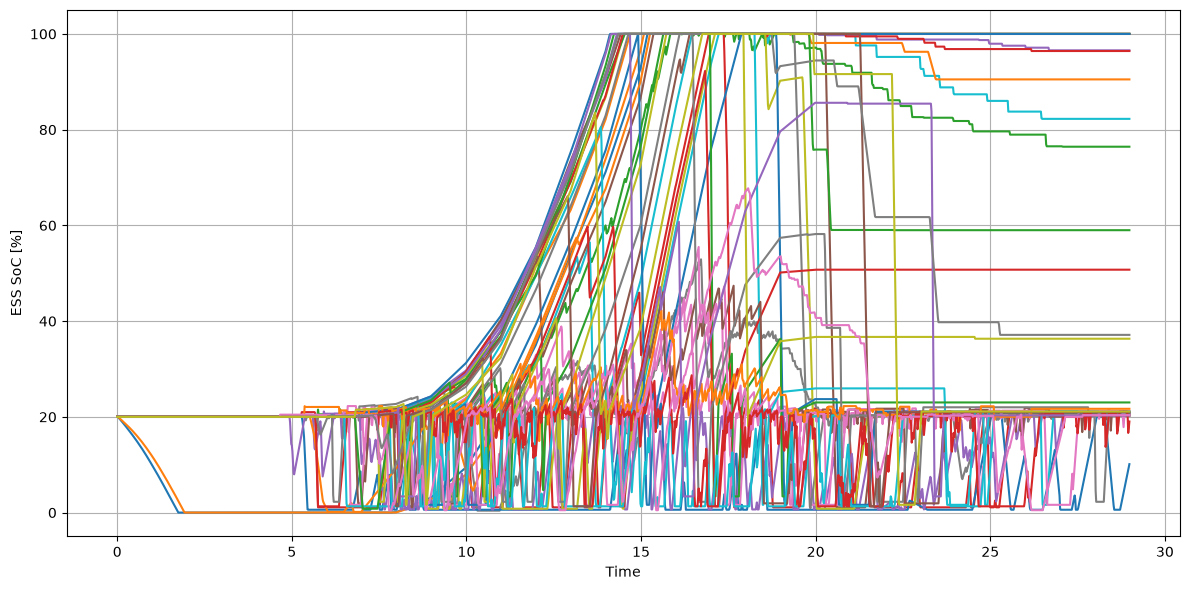

winter


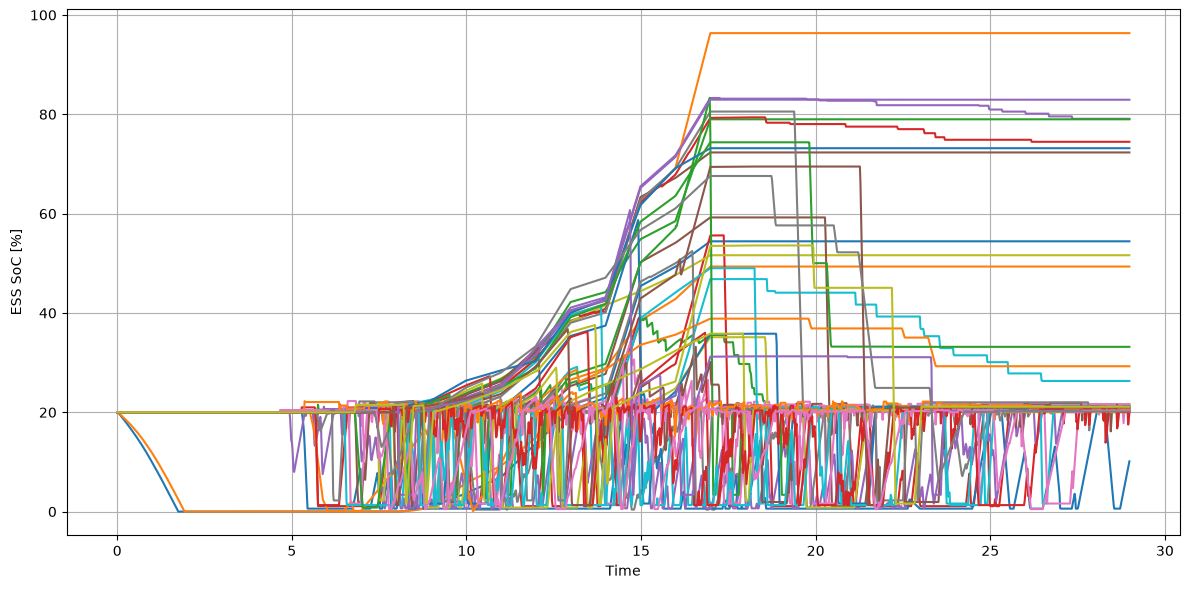

reduced


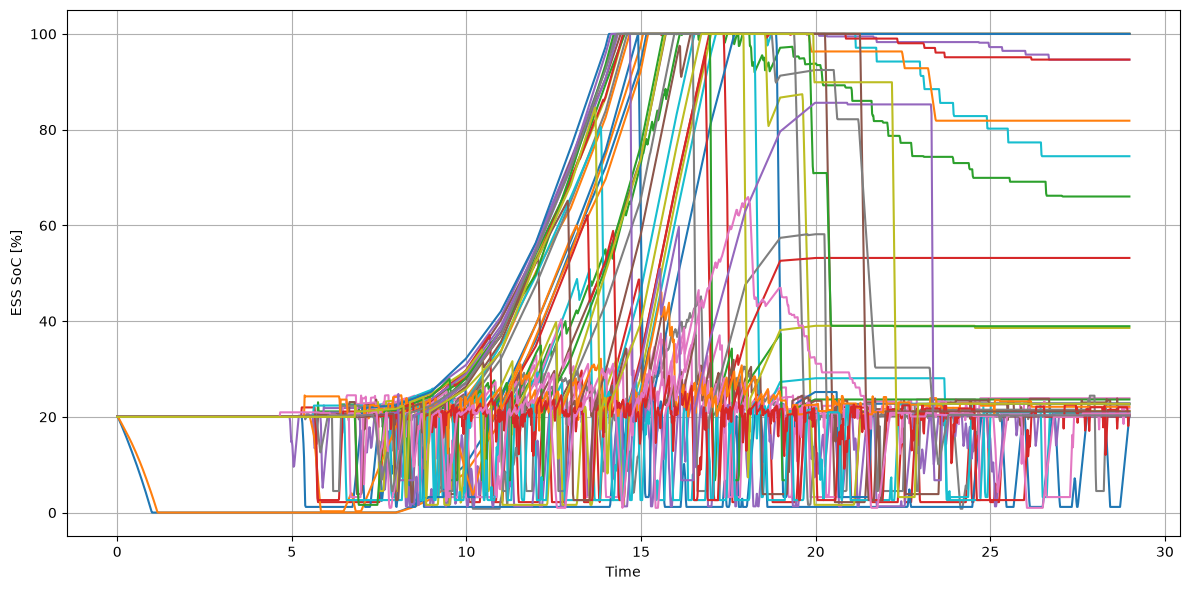

storage


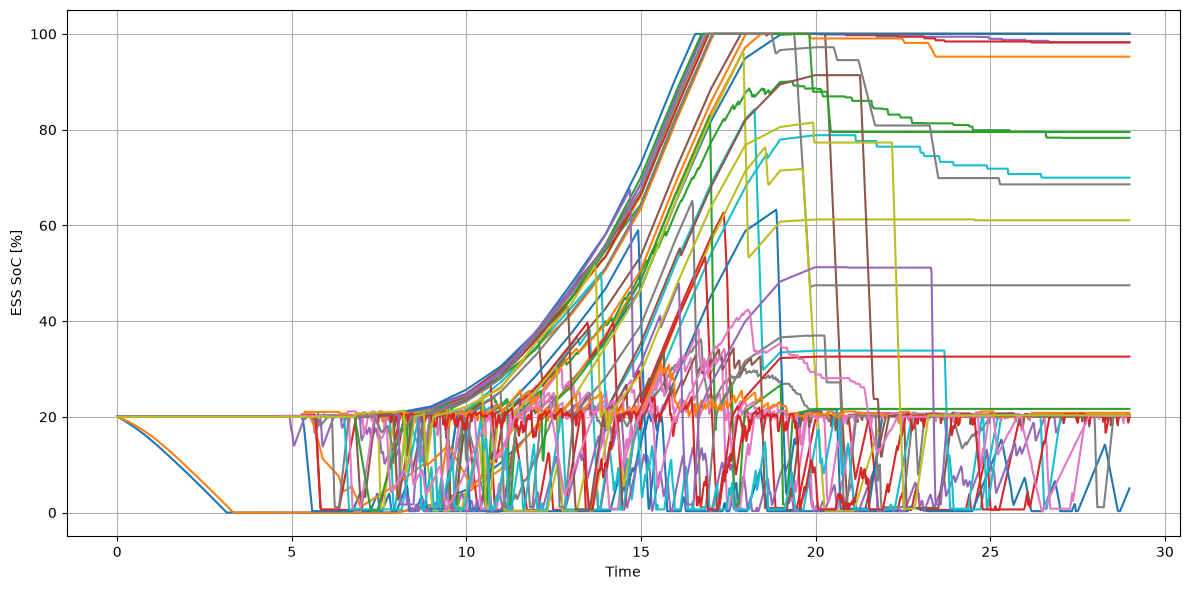

nodepot


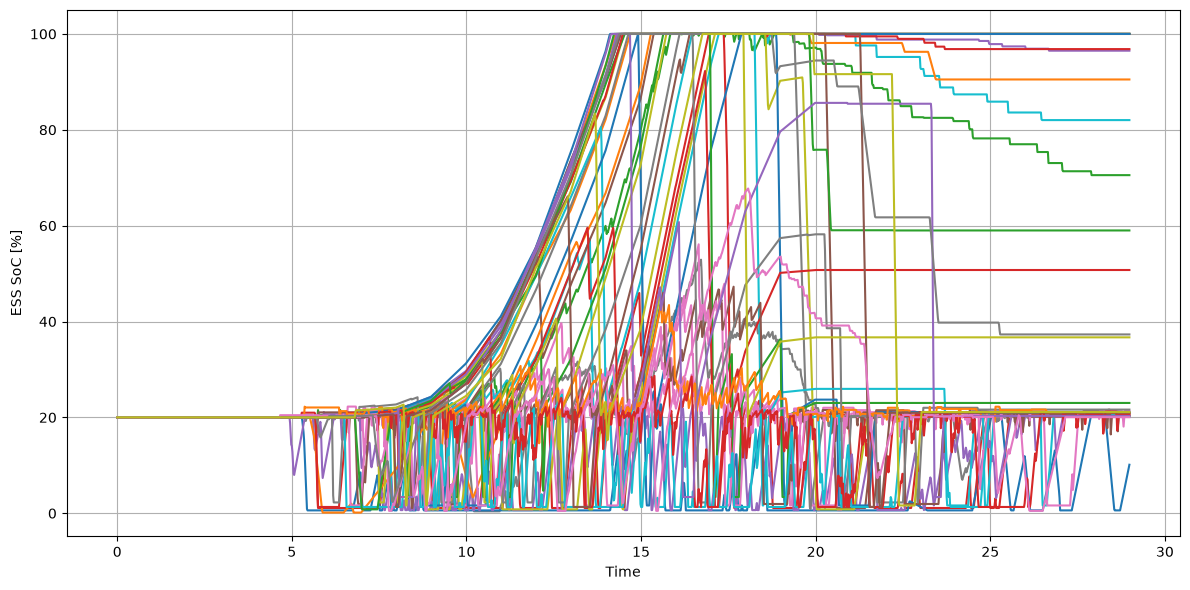

In [3]:
def ess_soc_over_time(output_dir=r"C:\Users\Ralop\Nextcloud\Masterarbeit\Grafiken\Plots"):

    con = duckdb.connect(
        r"G:\Dokumente\Studium\FU Berlin\BeSTeBuS\best-ebus"
        r"\scenario\eBuS\database\eBuS.duckdb"
    )

    df = con.execute(
        """
        SELECT
            timestep_time,
            station_essSoc,
            station_id,
            station_capacity,
            scenario,
            seed
        FROM multirun_ess
        WHERE seed = 65
        ORDER BY timestep_time
        """
    ).fetchdf()

    con.close()

    df["timestep_time"] = df["timestep_time"] / 3600
    df["station_essSoc_pct"] = df["station_essSoc"] / df["station_capacity"] * 100

    for scenario in ["summer", "winter", "reduced", "storage", "nodepot"]:
            subset = df[df["scenario"] == scenario]

            fig, ax = plt.subplots(figsize=(12, 6))

            # Plot one line for each station
            for station_id, station_data in subset.groupby("station_id"):
                station_data = station_data.sort_values("timestep_time")

                ax.plot(
                    station_data["timestep_time"],
                    station_data["station_essSoc_pct"],
                    label=station_id
                )

            ax.set_xlabel("Time")
            ax.set_ylabel("ESS SoC [%]")
            ax.grid(True)

            plt.tight_layout()

            fig.savefig(
                os.path.join(
                    output_dir,
                    f"{scenario}_ess_over_time.pdf"
                )
            )
            print(scenario)
            plt.show()
            plt.close(fig)
ess_soc_over_time()

In [ ]:
@staticmethod
def _charging_events_energy(events, time_grid):
    """Distribute each event's energy evenly over its duration and
    return the resulting energy [kWh] per timestep, sampled at
    ``time_grid`` [h], matching the per-timestep energy convention of
    ``station_energyCharged``.
    """
    dt_h = time_grid[1] - time_grid[0]
    duration_h = events["end_time"] - events["start_time"]
    power_kw = (events["energy_charged_kwh"] / duration_h).to_numpy()

    start_idx = np.searchsorted(time_grid, events["start_time"].to_numpy())
    end_idx = np.searchsorted(time_grid, events["end_time"].to_numpy())

    delta = np.zeros(len(time_grid) + 1)
    np.add.at(delta, start_idx, power_kw)
    np.add.at(delta, end_idx, -power_kw)

    return np.cumsum(delta)[:len(time_grid)] * dt_h

@staticmethod
def stacked_ieh_power_no_depot(output_dir=r"C:\Users\Ralop\Nextcloud\Masterarbeit\Grafiken\Plots"):

    con = duckdb.connect(
        r"G:\Dokumente\Studium\FU Berlin\BeSTeBuS\best-ebus"
        r"\scenario\eBuS\database\eBuS.duckdb"
    )

    df = con.execute(
        """
        SELECT
            timestep_time,
            station_gridEnergyDrawn,
            station_pvCurtailed,
            station_pvGenerated,
            station_energyCharged,
            scenario
        FROM multirun_ess
        WHERE seed = 65
        ORDER BY timestep_time
        """
    ).fetchdf()

    con.close()

    solution_path = (
        r"G:\Dokumente\Studium\FU Berlin\BeSTeBuS\best-ebus"
        r"\scenario\eBuS\files\postprocessing_input\solution.json"
    )
    with open(solution_path, "r") as f:
        solution = json.load(f)

    events = pd.DataFrame(solution["charging_events"])
    events[["start_time", "end_time"]] = events[["start_time", "end_time"]] / 60

    for scenario in ["summer", "winter", "reduced", "storage", "nodepot"]:

        subset = df[df["scenario"] == scenario].copy()
        subset["timestep_time"] = subset["timestep_time"] / 3600
        energy_cols = ["station_gridEnergyDrawn",
                        "station_pvCurtailed",
                        "station_pvGenerated",
                        "station_energyCharged"]
        subset[energy_cols] = subset[energy_cols] / 1000
        totals = subset.groupby("timestep_time")[
            ["station_gridEnergyDrawn", "station_pvCurtailed",
                "station_pvGenerated", "station_energyCharged"]
        ].sum().reset_index()
        fig, ax = plt.subplots(figsize=(12, 6))

        pv_stored = (
            totals["station_pvGenerated"]
            - totals["station_energyCharged"]
            - totals["station_pvCurtailed"]
        ).clip(lower=0)

        ax.stackplot(
            totals["timestep_time"],
            totals["station_gridEnergyDrawn"],
            pv_stored,
            totals["station_pvCurtailed"],
            alpha=0.7,
            step="mid",
            labels=[
                "Grid Energy Drawn",
                "PV Stored",
                "PV Curtailed",
            ],
            colors=["tab:red", "gold", "tab:purple"],
        )

        event_energy = IntegratedEnergyHubAnalysis._charging_events_energy(
            events, totals["timestep_time"].to_numpy()
        )

        ax.plot(
            totals["timestep_time"],
            totals["station_energyCharged"],
            color="black",
            linewidth=0.5,
            linestyle=":",
            label="Energy Charged",
        )

        ax.plot(
            totals["timestep_time"],
            event_energy,
            color="tab:blue",
            linewidth=1,
            linestyle="--",
            label="Charging Events (Solution)",
        )

        series = [
            ("Grid Energy Drawn", totals["station_gridEnergyDrawn"], "tab:red"),
            ("PV Stored", pv_stored, "gold"),
            ("PV Curtailed", totals["station_pvCurtailed"], "tab:purple"),
        ]

        cumulative = np.zeros(len(totals))
        for label, values, color in series:
            cumulative += values.to_numpy()
            peak_idx = values.idxmax()
            peak_x = totals["timestep_time"].loc[peak_idx]
            peak_y = cumulative[peak_idx]
            peak_val = values.loc[peak_idx]

            ax.scatter(peak_x, peak_y, color=color, edgecolor="black", zorder=5)
            ax.annotate(
                f"{peak_val:.0f}",
                (peak_x, peak_y),
                textcoords="offset points", xytext=(0, 6),
                fontsize=8, color=color, ha="center",
            )

        ax.set_xlabel("Time [h]")
        ax.set_ylabel("Energy [kWh]")
        ax.legend()

        fig.savefig(
            os.path.join(output_dir, f"{scenario}_ess_stacked_depot.pdf")
        )
        plt.tight_layout()
        plt.show()

In [11]:
def solution_events_to_time_row(json_path):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    df = pd.DataFrame(data["charging_events"])
    df = df.sort_values(by="start_time").reset_index(drop=True)

    time_row = pd.DataFrame({
        "time": np.arange(1800),
        "energy_charged_kwh": 0.0
    })

    for _, event in df.iterrows():
        start = event["start_time"]
        end = event["end_time"]
        energy = event["energy_charged_kwh"]

        duration = end - start

        if duration <= 0:
            continue

        # Energy charged per minute during this event
        energy_per_minute = energy / duration

        # Only check timesteps that can overlap with this event
        first_timestep = max(0, int(np.floor(start)))
        last_timestep = min(1799, int(np.floor(end)))

        for timestep in range(first_timestep, last_timestep + 1):
            timestep_start = timestep
            timestep_end = timestep + 1

            # Calculate how many minutes of this timestep
            # overlap with the charging event
            overlap = max(
                0,
                min(end, timestep_end) -
                max(start, timestep_start)
            )

            time_row.loc[
                time_row["time"] == timestep,
                "energy_charged_kwh"
            ] += energy_per_minute * overlap
    time_row.to_csv("charging_energy_timerow.csv", index=False)
    return time_row

solution_events_to_time_row(r"G:\Dokumente\Studium\FU Berlin\BeSTeBuS\best-ebus\scenario\eBuS\files\postprocessing_input\solution.json")

,time,energy_charged_kwh
0,0,0.0
1,1,0.0
2,2,0.0
3,3,0.0
4,4,0.0
...,...,...
1795,1795,0.0
1796,1796,0.0
1797,1797,0.0
1798,1798,0.0
